# クマの目撃と気象に関するデータ分析

## データの出展
**令和4年4月から令和7年7月までの気象情報** : \
[気象庁・過去の気象データ・ダウンロード](https://www.data.jma.go.jp/risk/obsdl/index.php) \
**R3からR7までの熊類目撃情報** : \
[令和4年度クマ目撃等情報](https://www.pref.miyagi.jp/soshiki/sizenhogo/r4kuma.html) \
[令和5年度クマ目撃等情報](https://www.pref.miyagi.jp/soshiki/sizenhogo/r5kuma.html) \
[令和6年度クマ目撃等情報](https://www.pref.miyagi.jp/soshiki/sizenhogo/r6kuma.html) \
[令和7年度クマ目撃等情報](https://www.pref.miyagi.jp/soshiki/sizenhogo/r7kuma.html) \
***Note*** \
令和4年度以前のデータが取得できなかったため、令和4年度からとする。\
2025年7月に課題が出されたため、分析対象期間を令和7年度7月までとする。


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import japanize_matplotlib
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from datetime import datetime
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score, roc_curve, roc_auc_score
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.ensemble import RandomForestClassifier
import torch
import torch.nn as nn

import warnings
warnings.filterwarnings('ignore')

# Import Data

In [2]:
def read_bear_data(year):
    bear_df = pd.read_excel(f'r{year}koukaiyou.xlsx', index_col='番号').dropna()

    bear_df['年月日'] = pd.to_datetime({
        'year': 2018 + year + np.where(bear_df['月'] < 4, 1, 0), #年度は4月から始まるため、1～3月を翌年の西暦にする
        'month': bear_df['月'].map(int),
        'day': bear_df['日'].map(int)
    })
    
    bear_df = bear_df.groupby('年月日', as_index=False).size()
    bear_df.columns = ['年月日','発見回数']

    return bear_df

In [3]:
"""import bear data"""

r4_bear = read_bear_data(4)
r5_bear = read_bear_data(5)
r6_bear = read_bear_data(6)
r7_bear = read_bear_data(7)

bear_df = pd.concat([r4_bear, r5_bear, r6_bear, r7_bear])
bear_df

,年月日,発見回数
0,2022-04-06,1
1,2022-04-09,1
2,2022-04-10,2
3,2022-04-12,2
4,2022-04-13,1
...,...,...
313,2026-03-25,2
314,2026-03-26,1
315,2026-03-27,2
316,2026-03-28,1


In [4]:
"""import weather data"""
weather_items = ['平均気温(℃)','降水量の合計(mm)', '日照時間(時間)', '平均風速(m/s)', '平均蒸気圧(hPa)']
weather_data = pd.read_csv('./tenki.csv', delimiter=',',encoding="Shift-JIS",)[["年月日",*weather_items]]
weather_data['年月日'] = pd.to_datetime(weather_data['年月日'])

In [5]:
weather_data

,年月日,平均気温(℃),降水量の合計(mm),日照時間(時間),平均風速(m/s),平均蒸気圧(hPa)
0,2022-04-01,5.7,0.0,4.7,5.2,4.1
1,2022-04-02,5.4,0.0,12.0,3.8,4.7
2,2022-04-03,7.3,0.0,10.5,2.7,6.7
3,2022-04-04,9.1,13.0,0.0,2.9,10.3
4,2022-04-05,9.6,1.0,1.2,3.3,10.2
...,...,...,...,...,...,...
1456,2026-03-27,7.7,1.5,0.0,2.2,9.0
1457,2026-03-28,8.4,0.0,8.8,2.2,8.1
1458,2026-03-29,9.3,0.0,11.1,3.2,8.3
1459,2026-03-30,9.4,0.0,4.8,1.9,9.7


In [6]:
"""merge bear and weather data"""

data = pd.merge(bear_df, weather_data, on='年月日', how='outer')
data = data.fillna(0)
print(data.columns)

Index(['年月日', '発見回数', '平均気温(℃)', '降水量の合計(mm)', '日照時間(時間)', '平均風速(m/s)',
       '平均蒸気圧(hPa)'],
      dtype='object')


In [7]:
data

,年月日,発見回数,平均気温(℃),降水量の合計(mm),日照時間(時間),平均風速(m/s),平均蒸気圧(hPa)
0,2022-04-01,0.0,5.7,0.0,4.7,5.2,4.1
1,2022-04-02,0.0,5.4,0.0,12.0,3.8,4.7
2,2022-04-03,0.0,7.3,0.0,10.5,2.7,6.7
3,2022-04-04,0.0,9.1,13.0,0.0,2.9,10.3
4,2022-04-05,0.0,9.6,1.0,1.2,3.3,10.2
...,...,...,...,...,...,...,...
1456,2026-03-27,2.0,7.7,1.5,0.0,2.2,9.0
1457,2026-03-28,1.0,8.4,0.0,8.8,2.2,8.1
1458,2026-03-29,0.0,9.3,0.0,11.1,3.2,8.3
1459,2026-03-30,3.0,9.4,0.0,4.8,1.9,9.7


# Visualize data

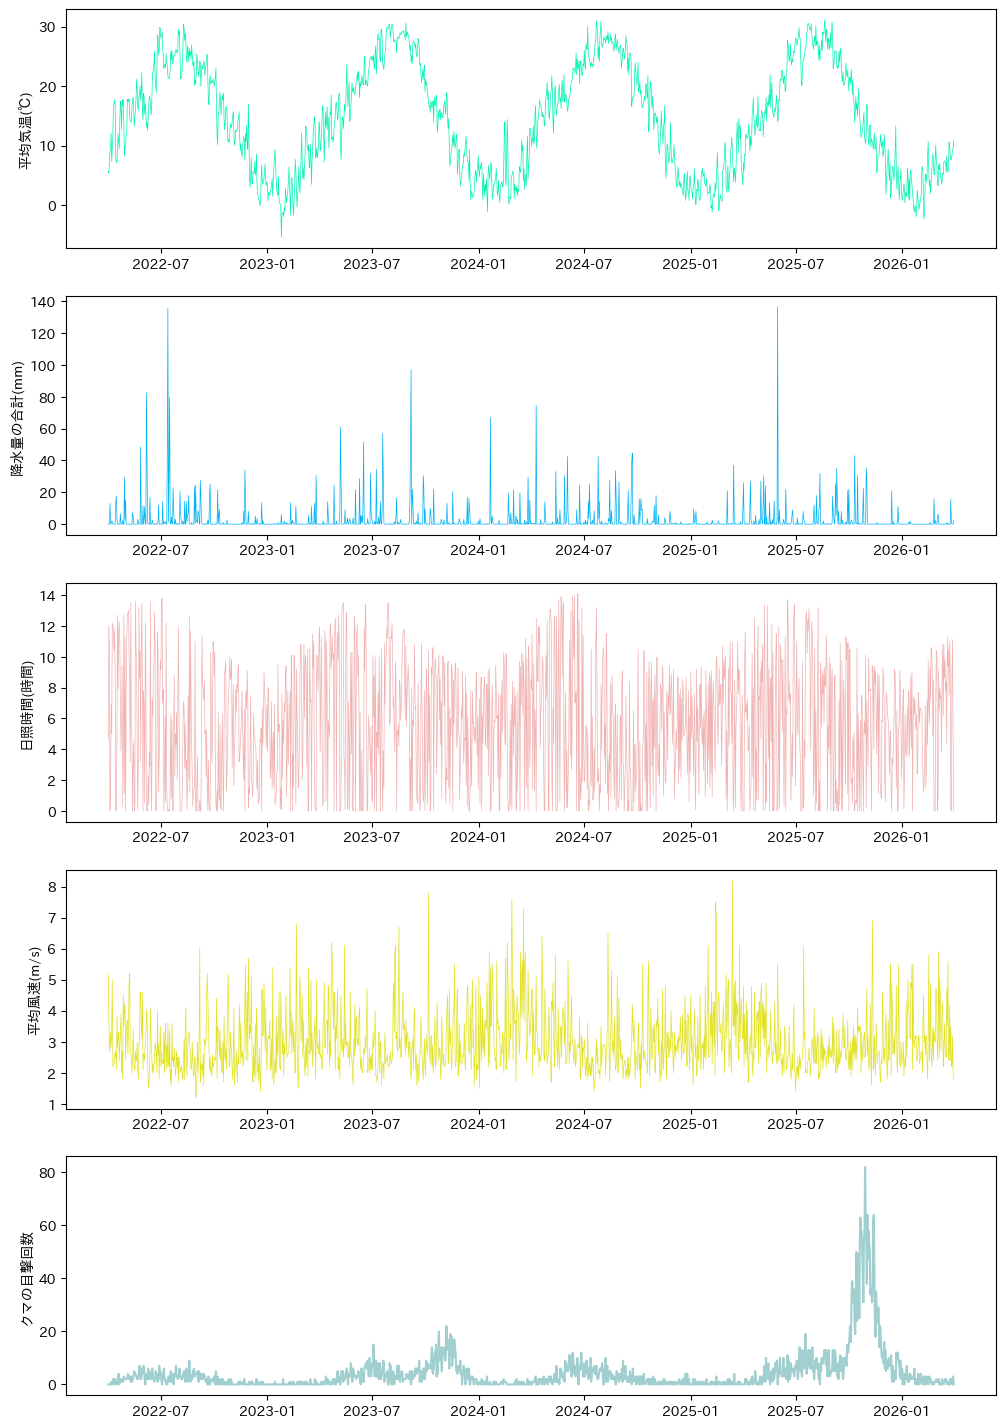

In [8]:
fig, axs = plt.subplots(5,1, figsize=(12,18))
colors = ['#01f2b2','#01b2f2','#f1b2b2','#e1e222','#a1cfcf']

for i in range(4):
    axs[i].set_ylabel(weather_items[i])
    axs[i].plot(data['年月日'], data[weather_items[i]], color = colors[i], linewidth=0.5)

axs[4].set_ylabel('クマの目撃回数')
axs[4].plot(data['年月日'], data['発見回数'], color = colors[4])

# 時系列分解 / Time Series Decomposition

In [9]:
date_rng = pd.DatetimeIndex(data['年月日'])
x = pd.Series(data['発見回数'].values, index=date_rng)
result_add = seasonal_decompose(x, model='additive')

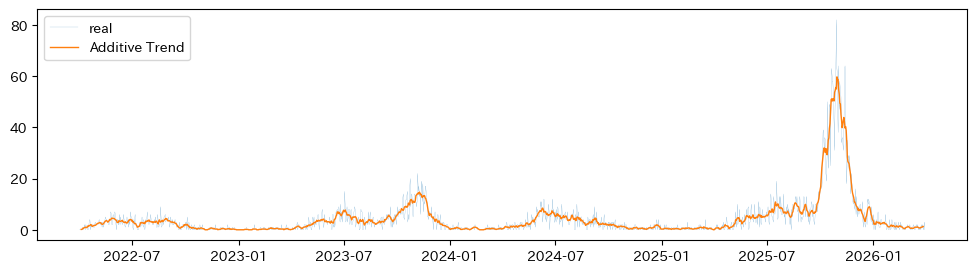

In [10]:
plt.figure(figsize=(12, 3))
plt.plot(x, label = 'real', linewidth = 0.1)
plt.plot(result_add.trend, label='Additive Trend', linewidth = 1)
plt.legend()

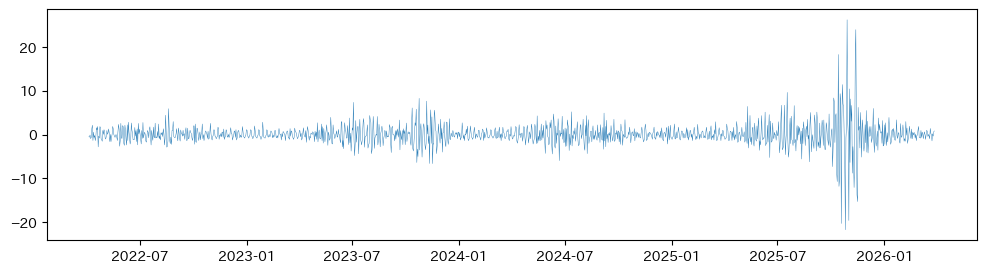

In [11]:
plt.figure(figsize=(12, 3))
plt.plot(result_add.resid, linewidth = 0.3)

# 相関係数 / Correlations

<Axes: >

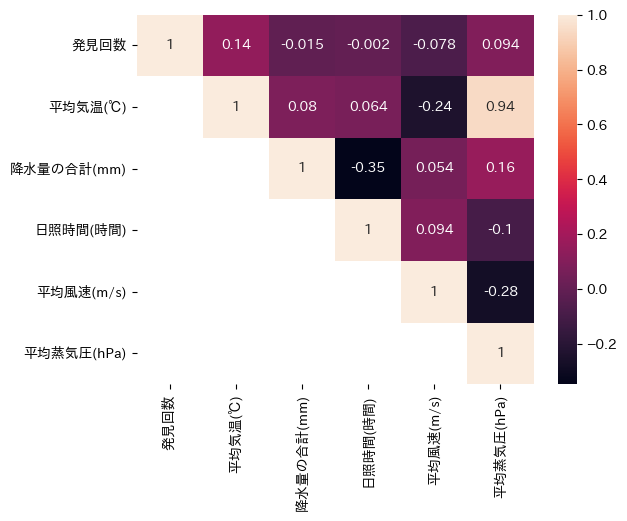

In [12]:
"""全データによる相関係数 / Correlations based on all data"""
corr = data.drop(columns=['年月日']).corr()
corr = corr.where(np.triu(np.ones(corr.shape)).astype(bool))
sns.heatmap(corr, annot=True)

In [13]:
"""年度ごとの相関系数 / Correlations by year"""
corretion_df = pd.DataFrame(columns=['令和',*weather_items])

for year in range(4,8):
    df = data.where(data['年月日'] >= datetime(2018 + year,4,1))
    df = df.where(df['年月日'] < datetime(2018 + year + 1,4,1))
    df = df.dropna()
    
    index = len(corretion_df)
    corretion_df.loc[index] = None
    corretion_df.loc[index]['令和'] = year
    for item in weather_items:
        cor = np.corrcoef(df['発見回数'],df[item])
        corretion_df.loc[index][item] = cor[0][1]

In [14]:
print("年度ごとのクマと気象情報の相関")
corretion_df

年度ごとのクマと気象情報の相関


,令和,平均気温(℃),降水量の合計(mm),日照時間(時間),平均風速(m/s),平均蒸気圧(hPa)
0,4.0,0.615985,0.049617,0.003934,-0.157245,0.583707
1,5.0,0.265114,-0.057213,0.035455,-0.185374,0.182987
2,6.0,0.570223,-0.044071,-0.009258,-0.216448,0.539084
3,7.0,0.070178,-0.009396,-0.046538,-0.060756,-0.006625


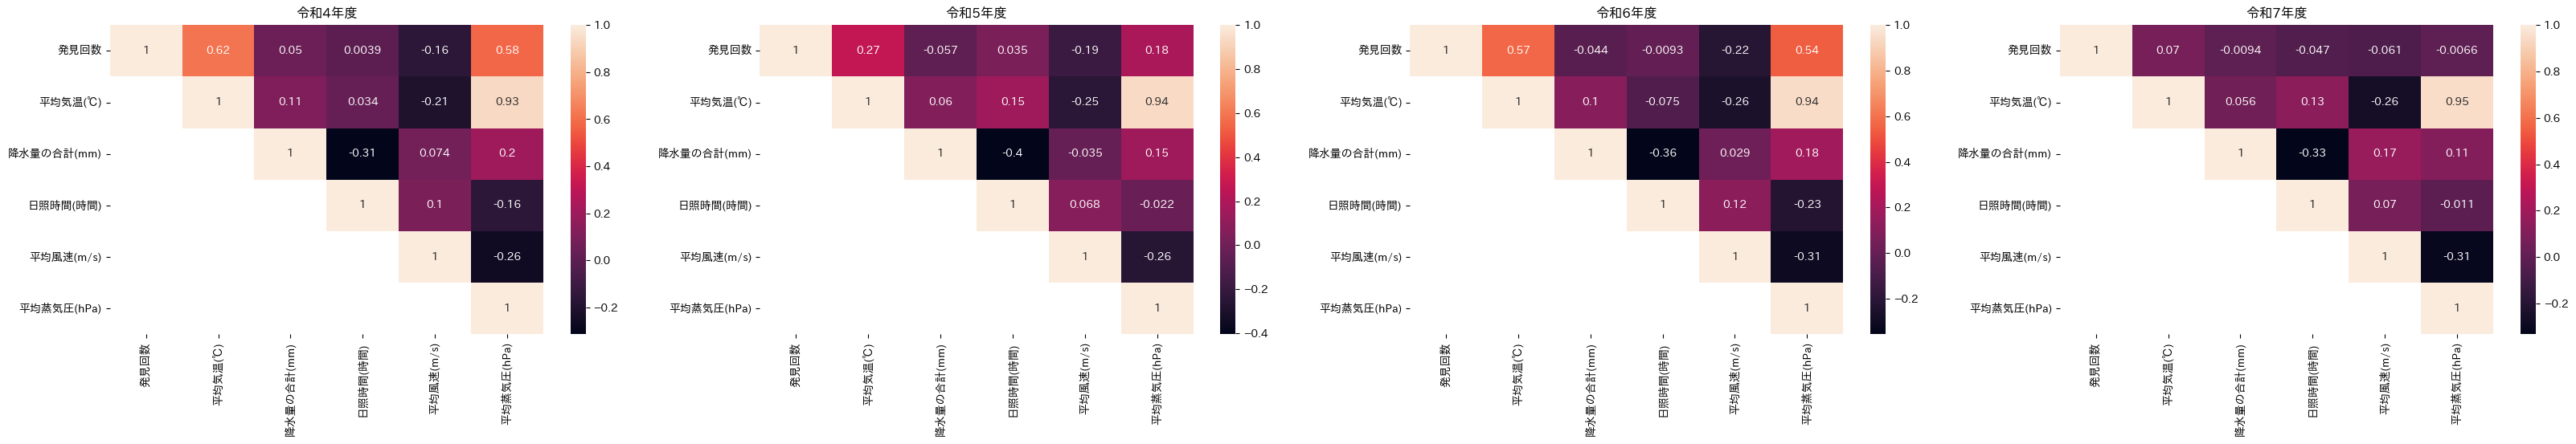

In [15]:
fig, axs = plt.subplots(1,4, figsize=(40,5))
yearly_cors = {}

for i in range(4):
    year = 4 + i
    year_annot = f"令和{year}年度"
    df = data.where(data['年月日'] >= datetime(2018 + year,4,1))
    df = df.where(df['年月日'] < datetime(2018 + year + 1,4,1))
    df = df.dropna()
    corr = df.drop(columns=['年月日']).corr()
    yearly_cors[year_annot] = corr['発見回数'].drop(index='発見回数')
    corr = corr.where(np.triu(np.ones(corr.shape)).astype(bool))
    sns.heatmap(corr, annot=True, ax=axs[i])
    axs[i].set_title(year_annot)

In [16]:
pd.DataFrame(yearly_cors)

,令和4年度,令和5年度,令和6年度,令和7年度
平均気温(℃),0.615985,0.265114,0.570223,0.070178
降水量の合計(mm),0.049617,-0.057213,-0.044071,-0.009396
日照時間(時間),0.003934,0.035455,-0.009258,-0.046538
平均風速(m/s),-0.157245,-0.185374,-0.216448,-0.060756
平均蒸気圧(hPa),0.583707,0.182987,0.539084,-0.006625


# 月別熊類目撃回数 / Bear reports by month

Text(0.5, 1.0, '全データ月別の熊類目撃回数')

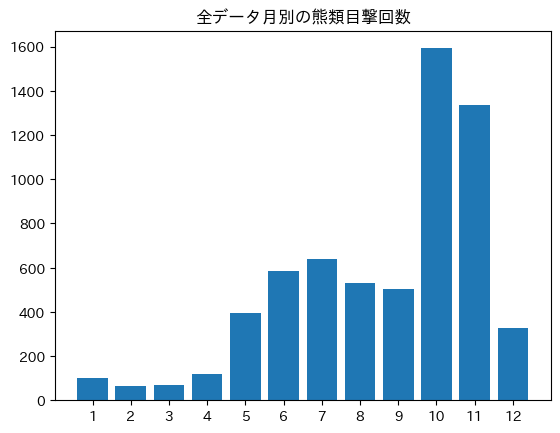

In [17]:
months = data['年月日'].map(lambda ymd: ymd.month)
x = pd.DataFrame({'発見回数':data['発見回数'],'月':months})
results = x.groupby("月")['発見回数'].sum()
plt.xticks(np.arange(1, 13, 1))
plt.bar(results.index,results)
plt.title("全データ月別の熊類目撃回数")

Text(0.5, 0.98, '年度別月ごとの熊類目撃回数')

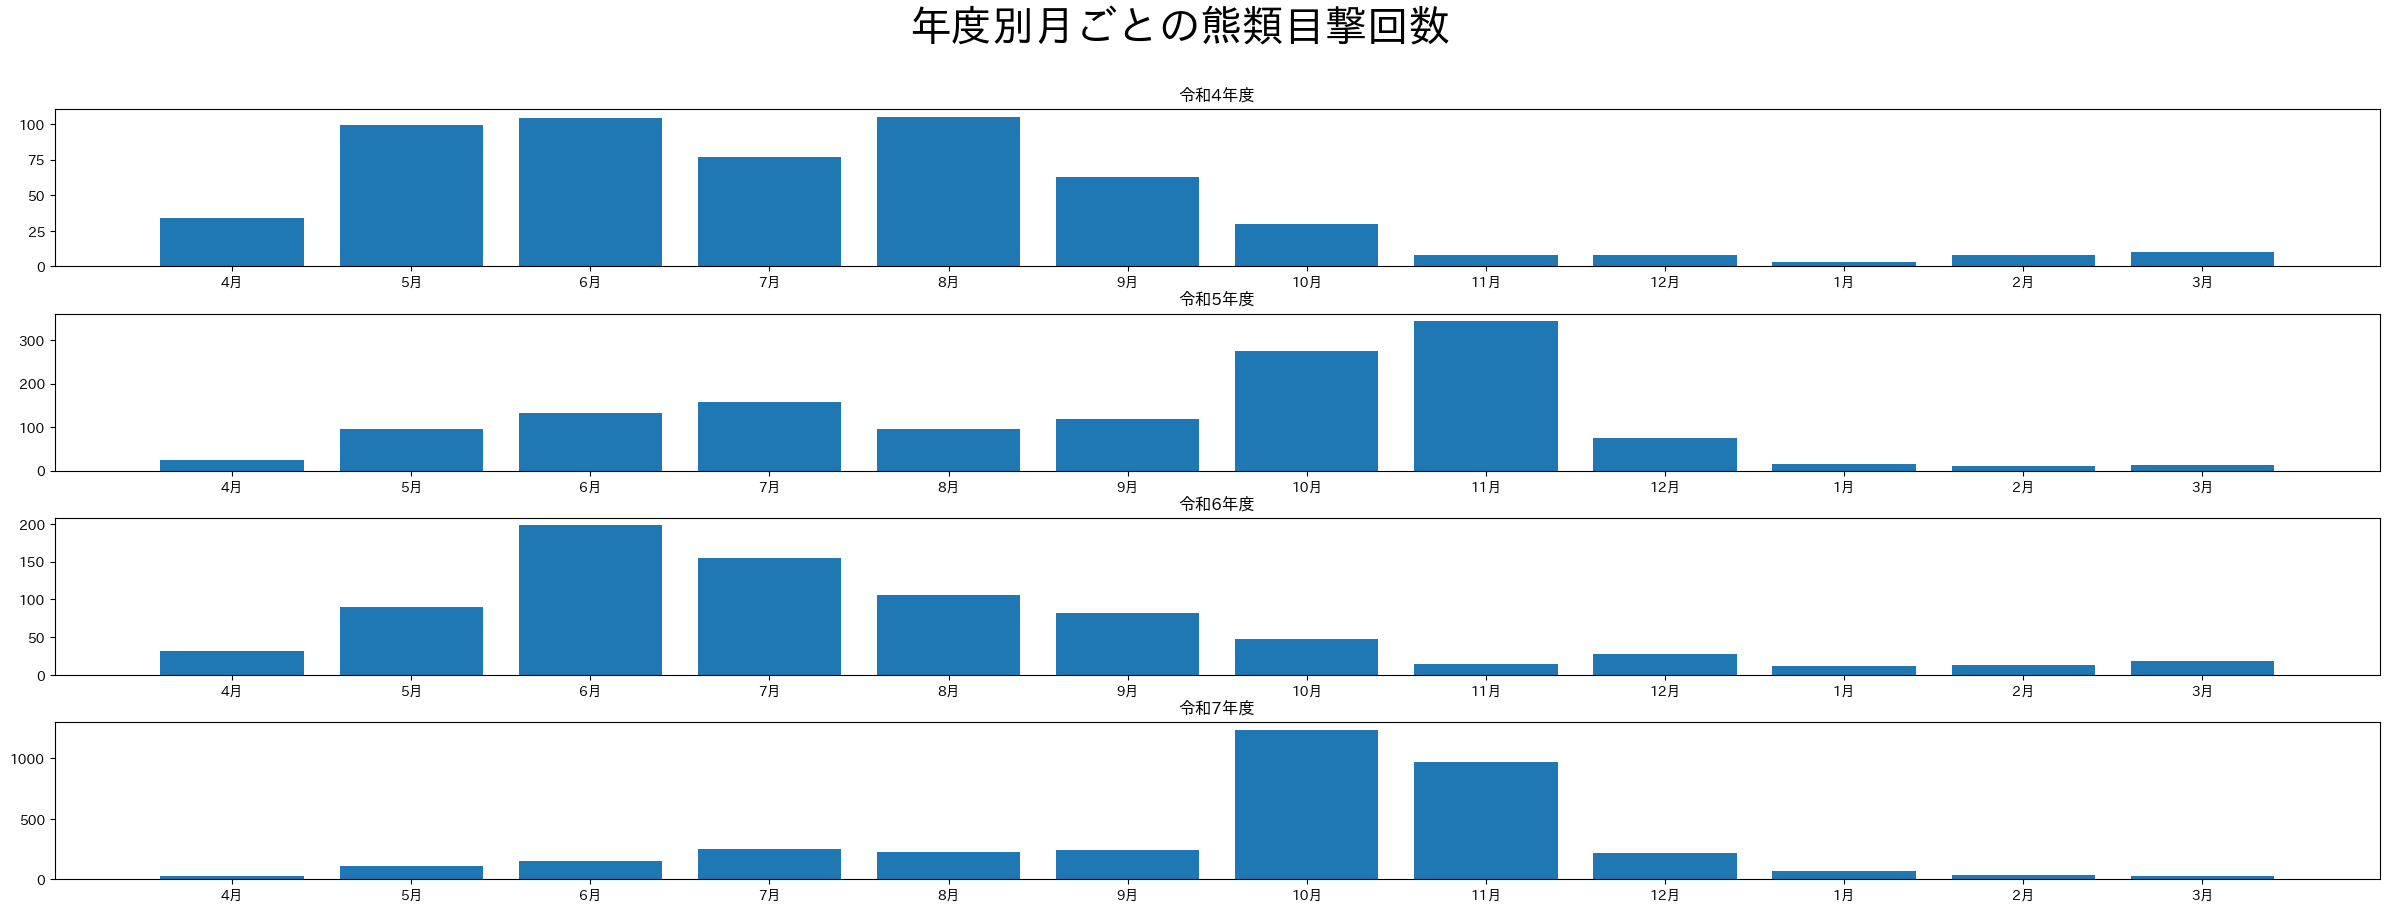

In [18]:
fig, axs = plt.subplots(4,1,figsize=(30,10))

for i in range(4):
    year = 4 + i
    df = data.where(data['年月日'] <= datetime(2018 + year + 1,4,1))
    df = df.where(data['年月日'] >= datetime(2018 + year,4,1))
    df = df.dropna()

    months = df['年月日'].map(lambda ymd: ymd.month)
    x = pd.DataFrame({'発見回数':df['発見回数'],'月':months})
    results = x.groupby("月")['発見回数'].sum().reindex([4,5,6,7,8,9,10,11,12,1,2,3])
    results.index = results.index.map(lambda m: f"{m}月")

    axs[i].set_title(f"令和{year}年度")
    axs[i].bar(results.index,results)

plt.subplots_adjust(hspace=0.3)
plt.suptitle("年度別月ごとの熊類目撃回数",fontsize=30, fontweight='bold')

# RandomForestを利用した熊類目撃予測 / Bear Encounter Prediction with RandomForest
**入力** : 平均気温(℃)、降水量の合計(mm)、日照時間(時間)、平均風速(m/s)、平均蒸気圧(hPa)、月 \
**出力** : クマの目撃可能性 [0,1] \
**学習データ** : R6まで \
**テストデータ** : R7データ

In [19]:
#気象項目の数値を正規化
#「目撃回数」から「目撃の有無」
_data = data.copy()
_data['目撃の有無'] = np.where(_data['発見回数'] > 0, 1, 0)

scaler = StandardScaler()
_data[weather_items] = scaler.fit_transform(_data[weather_items])
for i in range(12):
    _data[f"{str(i+1)}月"] = np.where(_data['年月日'].dt.month == (i+1),1,0)

In [20]:
train_data = _data.drop(columns=['発見回数']).where(_data['年月日'] < pd.to_datetime("2025-4-1")).dropna()
test_data = _data.drop(columns=['発見回数']).where(_data['年月日'] >= pd.to_datetime("2025-4-1")).dropna()

In [21]:
train_data[:5]

,年月日,平均気温(℃),降水量の合計(mm),日照時間(時間),平均風速(m/s),平均蒸気圧(hPa),目撃の有無,1月,2月,3月,4月,5月,6月,7月,8月,9月,10月,11月,12月
0,2022-04-01,-1.004083,-0.301053,-0.237104,2.191593,-1.131184,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2022-04-02,-1.037781,-0.301053,1.642193,0.779635,-1.062850,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2022-04-03,-0.824365,-0.301053,1.256036,-0.329761,-0.835069,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2022-04-04,-0.622181,1.033502,-1.447062,-0.128052,-0.425065,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2022-04-05,-0.566019,-0.198395,-1.138137,0.275364,-0.436454,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [22]:
test_data[:5]

,年月日,平均気温(℃),降水量の合計(mm),日照時間(時間),平均風速(m/s),平均蒸気圧(hPa),目撃の有無,1月,2月,3月,4月,5月,6月,7月,8月,9月,10月,11月,12月
1096,2025-04-01,-1.262429,0.776857,-1.447062,0.073656,-0.812291,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1097,2025-04-02,-0.835597,2.368057,-1.447062,1.788177,-0.527566,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1098,2025-04-03,-0.981619,-0.095737,-1.447062,-0.834032,-0.641456,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1099,2025-04-04,-0.689576,-0.249724,1.101574,0.880489,-0.789513,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1100,2025-04-05,-0.700808,-0.301053,1.539218,-0.329761,-0.789513,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [23]:
train_x = np.array(train_data.drop(columns=['年月日','目撃の有無']).values)
train_y = train_data['目撃の有無']

test_x = np.array(test_data.drop(columns=['年月日','目撃の有無']).values)
test_y = test_data['目撃の有無']

In [24]:
model = RandomForestClassifier(n_estimators=80,max_depth=5)
model.fit(train_x, train_y)

,n_estimators,80
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
pred_y = model.predict(test_x)

Text(0.5, 1.0, '予想結果混合行列')

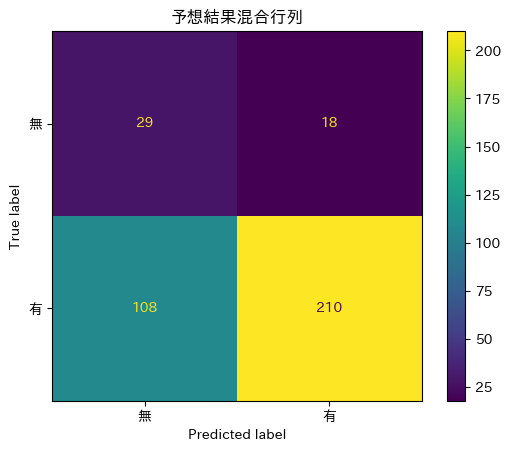

In [26]:
conf = confusion_matrix(test_y,pred_y)
disp = ConfusionMatrixDisplay(conf, display_labels=['無','有'])
disp.plot()
plt.title("予想結果混合行列")

適合率: 0.9210526315789473
再現率: 0.660377358490566
F1: 0.7692307692307693
AUC: 0.6386993175431553


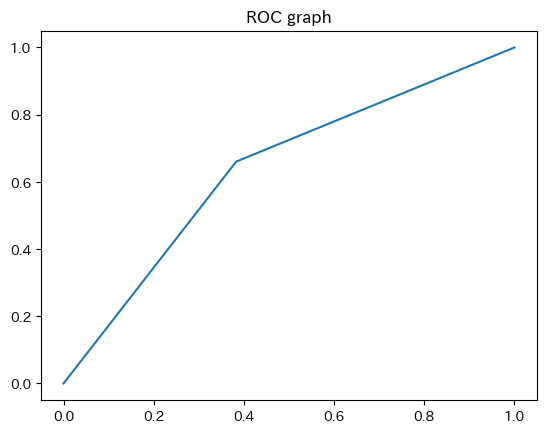

In [27]:
precision = precision_score(test_y, pred_y)
recall = recall_score(test_y, pred_y)
f1 = f1_score(test_y, pred_y)
roc = roc_curve(test_y, pred_y)
auc = roc_auc_score(test_y, pred_y)

print(f'適合率: {precision}')
print(f'再現率: {recall}')
print(f'F1: {f1}')
print(f'AUC: {auc}')
plt.title("ROC graph")
plt.plot(roc[0],roc[1])

令和4年度から6年度にかけて相関を解析した結果 \

- 降水量の合計(mm)と日照時間(時間)は目撃回数との相関が非常に小さい
- 平均蒸気圧(hPa)は平均気温(℃)と相関が強いため、どれかのみ入力とすればよい

今回、目撃回数との相関が小さい項目、重複な項目を減らして実行してみる

**入力** : 平均気温(℃)、平均風速(m/s)、月 \
**出力** : クマの目撃可能性 [0,1] \
**学習データ** : R6まで \
**テストデータ** : R7データ

In [28]:
train_x = np.array(train_data.drop(columns=['年月日','目撃の有無','降水量の合計(mm)','日照時間(時間)','平均蒸気圧(hPa)']).values)
train_y = train_data['目撃の有無']

test_x = np.array(test_data.drop(columns=['年月日','目撃の有無','降水量の合計(mm)','日照時間(時間)','平均蒸気圧(hPa)']).values)
test_y = test_data['目撃の有無']

In [29]:
model = RandomForestClassifier(n_estimators=80,max_depth=5)
model.fit(train_x, train_y)

,n_estimators,80
,criterion,'gini'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
pred_y = model.predict(test_x)

Text(0.5, 1.0, '予想結果混合行列')

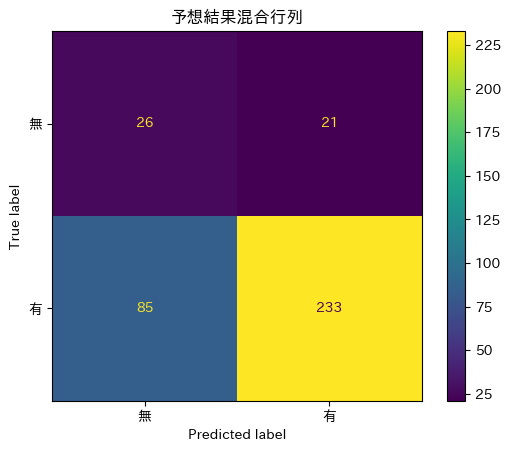

In [31]:
conf = confusion_matrix(test_y,pred_y)
disp = ConfusionMatrixDisplay(conf, display_labels=['無','有'])
disp.plot()
plt.title("予想結果混合行列")

適合率: 0.9173228346456693
再現率: 0.7327044025157232
F1: 0.8146853146853147
AUC: 0.6429479459387126


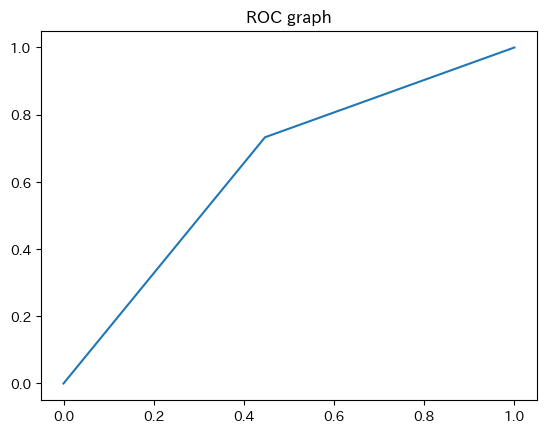

In [32]:
precision = precision_score(test_y, pred_y)
recall = recall_score(test_y, pred_y)
f1 = f1_score(test_y, pred_y)
roc = roc_curve(test_y, pred_y)
auc = roc_auc_score(test_y, pred_y)

print(f'適合率: {precision}')
print(f'再現率: {recall}')
print(f'F1: {f1}')
print(f'AUC: {auc}')
plt.title("ROC graph")
plt.plot(roc[0],roc[1])

# 熊類目撃の時系列予測 / Bear Encountering Time Series Forecasting

**入力** : 平均気温(℃)、平均風速(m/s)、月 \
**出力** : クマの目撃可能性 [0,1] \
**学習データ** : R6まで \
**テストデータ** : R7データ \

前に実施した正規化を無視する。Train-test分割の後で学習セットを正規化する。学習セットを正規化したパラメータでテストセットを正規化する

In [33]:
def create_dataset(input_data, real_data, dates, time_step = 14):
    length = len(input_data)
    dim = input_data.shape[-1]

    x = np.zeros([length - time_step, time_step, dim], dtype=np.float32)
    y = np.zeros([length - time_step, 1],dtype=np.float32)

    for i in range(length - time_step):
        x[i,:] = input_data[i:i+time_step]
        y[i] = real_data[i+time_step]
    
    return x, y, dates[time_step:]

In [34]:
time_step = 14 #時刻（日数）

for i in range(12):
    data[f"{str(i+1)}月"] = np.where(data['年月日'].dt.month == (i+1),1,0)

train_data = data.where(data['年月日'] < pd.to_datetime('2026-04-01')).dropna().reset_index(drop=True)
test_data = data.where(data['年月日'] >= pd.to_datetime('2025-04-01')).dropna().reset_index(drop=True)

input_scaler = StandardScaler()
output_scaler = RobustScaler()

train_data[weather_items] = input_scaler.fit_transform(train_data[weather_items])
test_data[weather_items] = input_scaler.transform(test_data[weather_items])
train_data["発見回数"] = output_scaler.fit_transform(train_data[["発見回数"]])
test_data["発見回数"] = output_scaler.transform(test_data[["発見回数"]])

train_x, train_y, train_dates = create_dataset(train_data.drop(columns=["年月日"]), train_data['発見回数'],train_data['年月日'],time_step)
test_x, test_y, test_dates = create_dataset(test_data.drop(columns=["年月日"]), test_data['発見回数'],test_data['年月日'],time_step)

In [35]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class RNN(nn.Module):
  def __init__(self, input_dim, hidden_dim, layer_dim, output_dim):
    super(RNN, self).__init__()
    self.hidden_dim = hidden_dim
    self.layer_dim = layer_dim

    self.rnn = nn.RNN(
        input_size=input_dim,
        hidden_size=hidden_dim,
        num_layers=layer_dim,
        batch_first=True)
    self.fc = nn.Linear(hidden_dim, output_dim)

  def forward(self, X):
    h0 = torch.zeros(self.layer_dim, X.size(0), self.hidden_dim).to(device)
    out, h = self.rnn(X, h0)
    out = self.fc(out[:, -1, :])
    return out

In [36]:
input_dim = train_x.shape[-1]
output_dim = 1
hidden_dim = 128
layer_dim = 1
lr = 1e-3
epochs=150
rnn = RNN(input_dim, hidden_dim, layer_dim, output_dim).to(device)

In [37]:
def train(model,
          learning_rate,
          X_train,
          y_train,
          epochs=100):

  # Loss and optimizer
  criterion = nn.MSELoss()
  optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=0.9, weight_decay=1e-4)

  train_losses = np.zeros(epochs)

  for epoch in range(epochs):
    optimizer.zero_grad()

    # Forward pass
    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    # Backpropagation
    loss.backward()
    optimizer.step()

    #Train loss
    train_losses[epoch] = loss.item()

    print(f'At epoch {epoch+1} of {epochs}, Train Loss: {loss.item():.3f}')

  return train_losses

At epoch 1 of 150, Train Loss: 3.104
At epoch 2 of 150, Train Loss: 3.082
At epoch 3 of 150, Train Loss: 3.042
At epoch 4 of 150, Train Loss: 2.985
At epoch 5 of 150, Train Loss: 2.914
At epoch 6 of 150, Train Loss: 2.831
At epoch 7 of 150, Train Loss: 2.740
At epoch 8 of 150, Train Loss: 2.641
At epoch 9 of 150, Train Loss: 2.537
At epoch 10 of 150, Train Loss: 2.430
At epoch 11 of 150, Train Loss: 2.321
At epoch 12 of 150, Train Loss: 2.213
At epoch 13 of 150, Train Loss: 2.106
At epoch 14 of 150, Train Loss: 2.000
At epoch 15 of 150, Train Loss: 1.898
At epoch 16 of 150, Train Loss: 1.800
At epoch 17 of 150, Train Loss: 1.706
At epoch 18 of 150, Train Loss: 1.617
At epoch 19 of 150, Train Loss: 1.532
At epoch 20 of 150, Train Loss: 1.453
At epoch 21 of 150, Train Loss: 1.380
At epoch 22 of 150, Train Loss: 1.312
At epoch 23 of 150, Train Loss: 1.250
At epoch 24 of 150, Train Loss: 1.194
At epoch 25 of 150, Train Loss: 1.143
At epoch 26 of 150, Train Loss: 1.096
At epoch 27 of 150, T

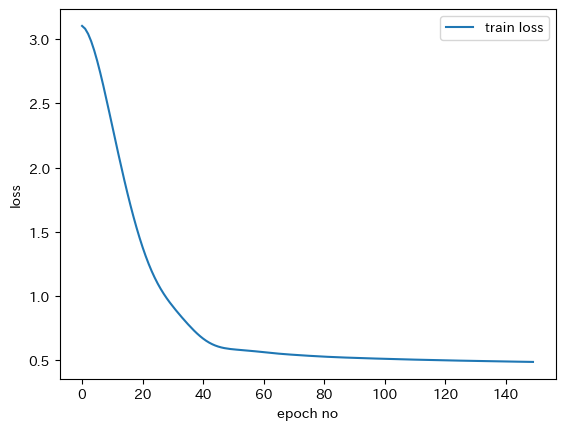

In [38]:
# move data to GPU
train_x, train_y = torch.tensor(train_x).to(device), torch.tensor(train_y).to(device)
test_x, test_y = torch.tensor(test_x).to(device), torch.tensor(test_y).to(device)

train_losses = train(rnn,
                    lr,
                    train_x,
                    train_y,
                    epochs)

# Plot the train loss and test loss per iteration
plt.plot(train_losses, label='train loss')
plt.xlabel('epoch no')
plt.ylabel('loss')
plt.legend()
plt.show()

<BarContainer object of 1447 artists>

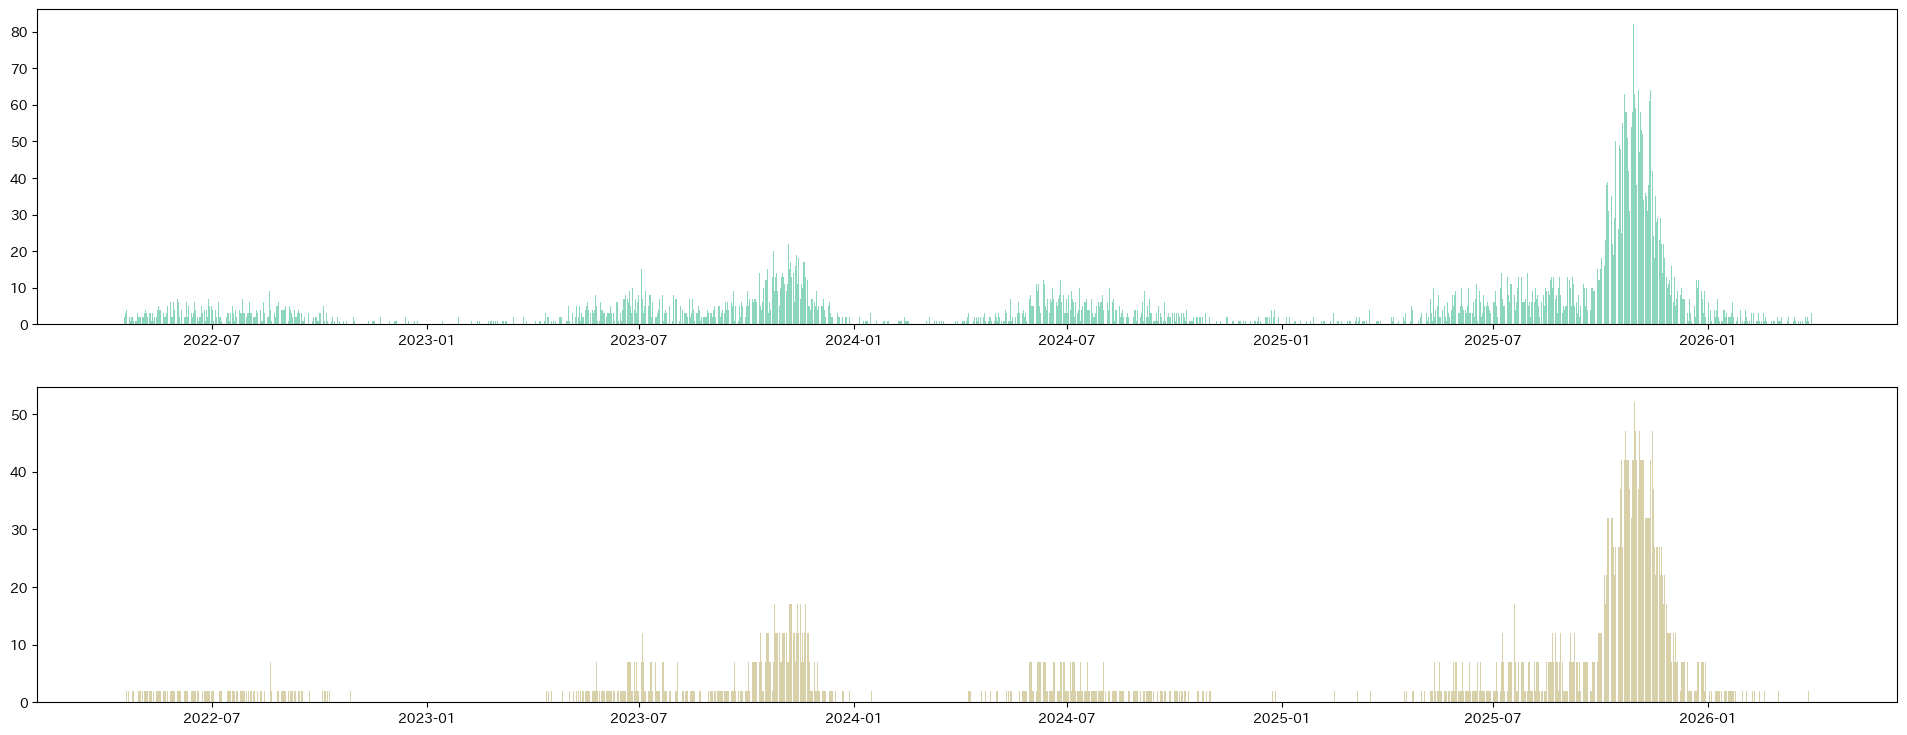

In [49]:
output = rnn(train_x).cpu().detach().numpy()
output = np.floor(output)

fig, axs = plt.subplots(2,figsize=(24,9))

real_y = output_scaler.inverse_transform(train_y.detach().cpu())
output = output_scaler.inverse_transform(output)
output = np.where(output > 0,output,0)

axs[0].bar(train_dates,real_y.squeeze(), color="#8dd6be")
axs[1].bar(train_dates,output.squeeze(), color="#d7d0a8")

<BarContainer object of 351 artists>

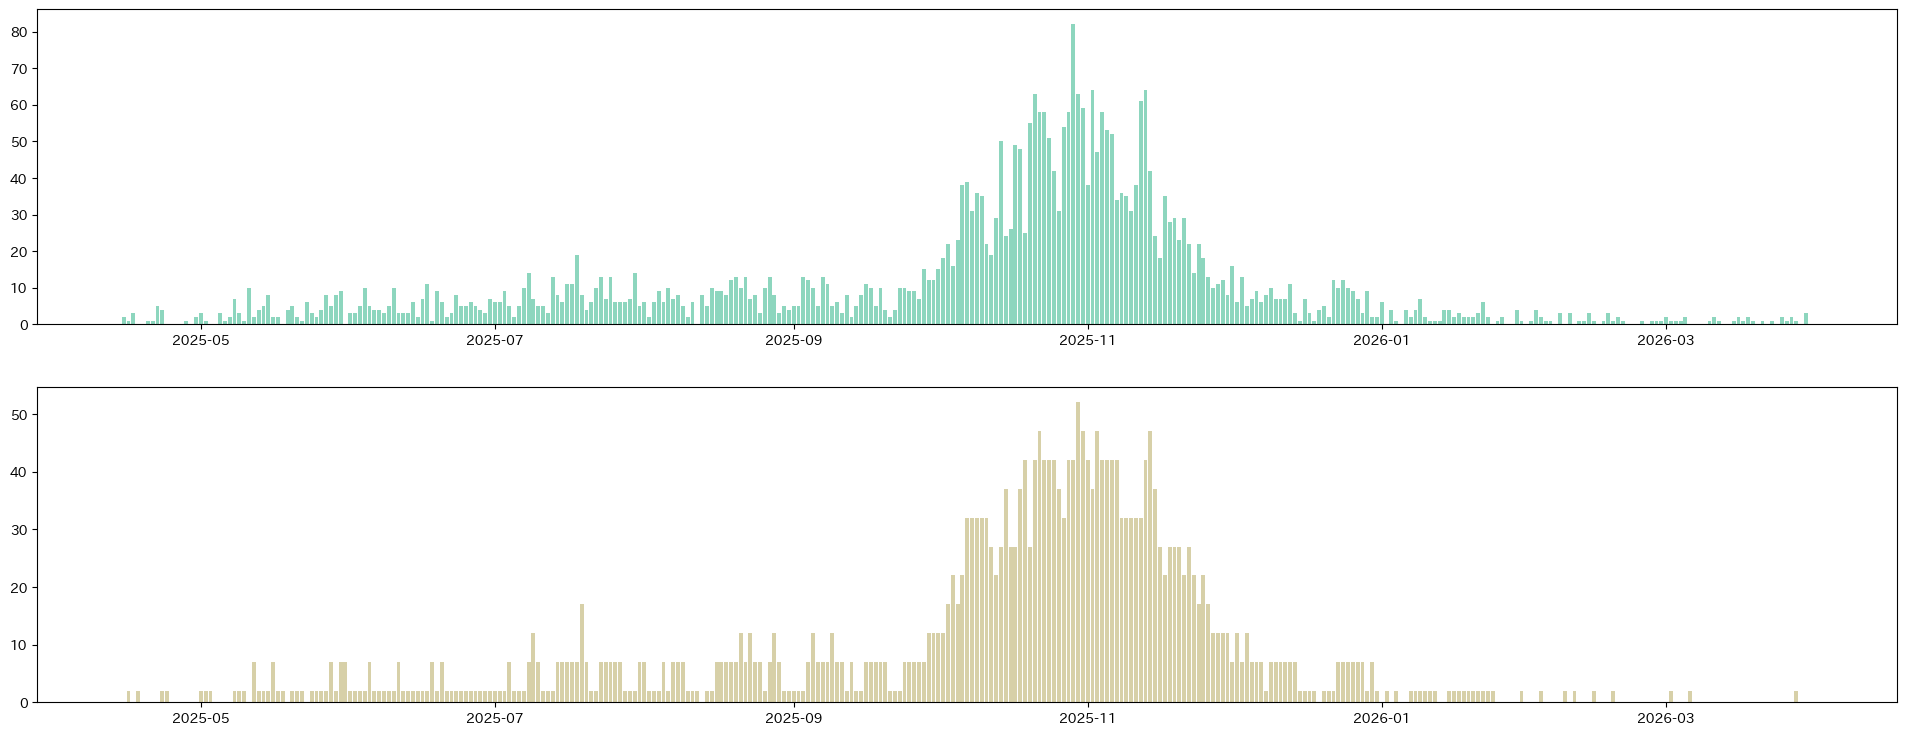

In [50]:
output = rnn(test_x).cpu().detach().numpy()
output = np.floor(output)
fig, axs = plt.subplots(2,figsize=(24,9))

real_y = output_scaler.inverse_transform(test_y.detach().cpu())
output = output_scaler.inverse_transform(output)
output = np.where(output <= 0,0,output)

axs[0].bar(test_dates,real_y.squeeze(), color="#8dd6be")
#axs[0].set_ylim(0,25)
axs[1].bar(test_dates,output.squeeze(), color="#d7d0a8")
#axs[1].set_ylim(1,25)